# DIY Portrait Lens from Catalog Achromats

This notebook models a mechanically buildable portrait lens made from two commercially available 2-inch achromatic doublets. Rather than pursuing uniform correction across the APS-C frame, the design favors useful central sharpness while allowing off-axis aberrations to contribute to the rendering.

The workflow covers catalog-lens import, mechanical apertures and adapters, helicoid-constrained refocusing, through-focus/FFT-MTF evaluation, and a simple Monte Carlo estimate of sensitivity to group tilt and decenter.

**Target:** Sony E-mount APS-C, approximately 90 mm effective focal length, with an iris between the two achromats.


In [1]:
import matplotlib.pyplot as plt
import optiland.backend as be
from optiland import optimization, analysis, wavefront, optic
from optiland.analysis import ThroughFocusSpotDiagram
from optiland.fileio import load_zemax_file
from optiland.mtf import FFTMTF
from optiland.physical_apertures import RadialAperture

## 1. Import the catalog achromats

The front group is a Thorlabs AC508-100-A. The rear ACT508-300-A is reversed before the prescriptions are combined.


In [2]:
FRONT_URL = (
    "https://media.thorlabs.com/globalassets/items/a/ac/ac5/"
    "ac508-100-a/20541-s03.zmx?v=0116102041"
)
REAR_URL = (
    "https://media.thorlabs.com/globalassets/items/a/ac/act/"
    "act508-300-a-ml/ttn163333-s03.zmx?v=0116102355"
)


def load_catalog_lens(url: str):
    """Load a local Zemax prescription from the catalog URL."""
    source = url
    return load_zemax_file(str(source))


front_group = load_catalog_lens(FRONT_URL)
rear_group = load_catalog_lens(REAR_URL)
rear_group.updater.flip()

# combining the front and rear groups
lens = front_group + rear_group

## 2. Build the optical model

The two achromats are combined with an iris between them. Real-image-height fields represent the center and APS-C off-axis positions, and the catalog elements are restricted to 90% of their nominal 2-inch diameter.


In [3]:
# Surface indices in the initial combined prescription, before inserting the stop.
FRONT_GROUP_REAR_SURFACE = 3
REAR_GROUP_REAR_SURFACE = 6

# Initial mechanical estimates in mm
lens.updater.set_thickness(be.inf, 0)  # set object distance
lens.updater.set_thickness(25.0, FRONT_GROUP_REAR_SURFACE)
lens.updater.set_thickness(23.0, REAR_GROUP_REAR_SURFACE)

lens.set_aperture("float_by_stop_size", 25.0)  # maximum opening of the iris aperture
lens.fields.set_type(field_type="real_image_height")
lens.fields.add(y=10.0, vx=0.65, vy=0.65)
lens.fields.add(y=14.1, vx=0.65, vy=0.65)  # approximately the APS-C half-diagonal [mm]

In [4]:
# Restrict the catalog lenses to 90% of their nominal 2-inch diameter.
LENS_SEMI_DIAMETER = 25.4 * 0.9

for surface in lens.surfaces[1:-1]:
    surface.set_semi_aperture(LENS_SEMI_DIAMETER)
    surface.aperture = RadialAperture(LENS_SEMI_DIAMETER)

# Insert the physical iris between the two groups.
STOP_SURFACE = 4
lens.surfaces.add(
    index=STOP_SURFACE,
    is_stop=True,
    thickness=25.0,
    aperture=25.0,
    comment="SM2 iris",
)

# After insertion, the rear group and image surface indices shift by one.
REAR_GROUP_REAR_SURFACE = 7
INITIAL_IMAGE_SURFACE = 8

## 3. Add the camera-side mechanics

The model is extended with the M42-to-Sony-E interface, the 18 mm flange focal distance, sensor aperture, and the relevant mechanical clear apertures so that clipping is included in the ray trace.


╒════╤═══════════════╤════════════════════════════════════╤══════════╤═════════════╤════════════╤═════════╤═════════════════╕
│    │ Type          │ Comment                            │   Radius │   Thickness │ Material   │   Conic │   Semi-aperture │
╞════╪═══════════════╪════════════════════════════════════╪══════════╪═════════════╪════════════╪═════════╪═════════════════╡
│  0 │ Planar        │                                    │  inf     │       inf   │ Air        │       0 │         39.0281 │
│  1 │ Standard      │                                    │   71.12  │        16   │ N-BAF10    │       0 │         22.86   │
│  2 │ Standard      │                                    │  -44.17  │         4   │ SF10       │       0 │         22.86   │
│  3 │ Standard      │                                    │ -363.1   │        37   │ Air        │       0 │         22.86   │
│  4 │ Stop - Planar │ SM2 iris                           │  inf     │        14   │ Air        │       0 │         12

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Layout with mechanical components'}, xlabel='Z [mm]', ylabel='Y [mm]'>)

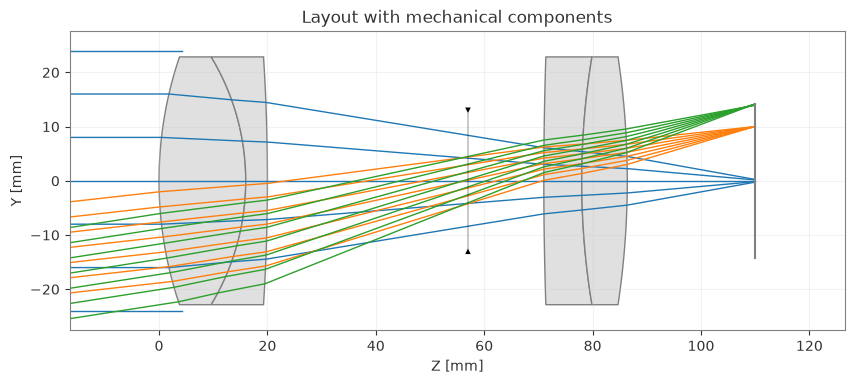

In [5]:
# Add the M42-to-E adapter and the flange focal distance.
M42_E_ADAPTER_SURFACE = 8
E_MOUNT_SURFACE = 9
FINAL_IMAGE_SURFACE = 10

lens.surfaces.add(
    index=M42_E_ADAPTER_SURFACE,
    thickness=1.0,
    comment="M42-to-Sony-E adapter",
)
lens.surfaces.add(
    index=E_MOUNT_SURFACE,
    thickness=18.0,
    comment="Sony E-mount flange focal distance",
)

# Mechanical distances [mm].
lens.updater.set_thickness(4.6, REAR_GROUP_REAR_SURFACE)
lens.updater.set_thickness(1.0, M42_E_ADAPTER_SURFACE)
lens.updater.set_thickness(18.0, E_MOUNT_SURFACE)
lens.updater.set_thickness(37.0, FRONT_GROUP_REAR_SURFACE)
lens.updater.set_thickness(14.0, STOP_SURFACE)

# Mechanical clear semi-apertures [mm].
lens.surfaces[REAR_GROUP_REAR_SURFACE].set_semi_aperture(19.05)
lens.surfaces[M42_E_ADAPTER_SURFACE].set_semi_aperture(20.65)
lens.surfaces[E_MOUNT_SURFACE].set_semi_aperture(23.05)
lens.surfaces[FINAL_IMAGE_SURFACE].set_semi_aperture(14.1)

lens.info()
lens.draw(
    num_rays=7,
    title="Layout with mechanical components",
)

## 4. Refocus within the helicoid travel

Only the front-group-to-stop spacing is optimized, with 37–51 mm bounds corresponding to the available helicoid travel. The merit function uses on-axis RMS spot size, deliberately leaving off-axis aberrations largely unconstrained.


╒════╤════════════════════════╤═══════════════════╕
│    │   Merit Function Value │   Improvement (%) │
╞════╪════════════════════════╪═══════════════════╡
│  0 │             0.00940017 │           96.6875 │
╘════╧════════════════════════╧═══════════════════╛
╒════╤════════════════╤══════════╤══════════════╤══════════════╤══════════╤═══════════════╤═════════╤═════════╤════════════════╕
│    │ Operand Type   │   Target │ Min. Bound   │ Max. Bound   │   Weight │   Eff. Weight │   Value │   Delta │   Contrib. [%] │
╞════╪════════════════╪══════════╪══════════════╪══════════════╪══════════╪═══════════════╪═════════╪═════════╪════════════════╡
│  0 │ rms spot size  │        0 │              │              │        1 │             1 │   0.082 │   0.082 │          70.91 │
│  1 │ rms spot size  │        0 │              │              │        1 │             1 │   0.036 │   0.036 │          13.61 │
│  2 │ rms spot size  │        0 │              │              │        1 │             1 │   0

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Final design after helicoid-constrained refocus'}, xlabel='Z [mm]', ylabel='Y [mm]'>)

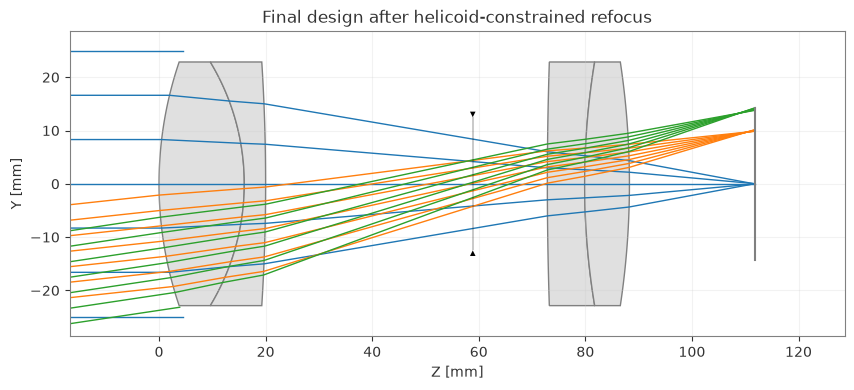

In [6]:
problem = optimization.OptimizationProblem()

for wavelength in lens.wavelengths.get_wavelengths():
    problem.add_operand(
        operand_type="rms_spot_size",
        target=0,
        weight=1,
        input_data={
            "optic": lens,
            "Hx": 0,
            "Hy": 0,
            "num_rays": 6,
            "wavelength": wavelength,
            "distribution": "hexapolar",
            "surface_number": FINAL_IMAGE_SURFACE,
        },
    )

problem.add_variable(
    lens,
    "thickness",
    surface_number=FRONT_GROUP_REAR_SURFACE,
    min_val=37.0,
    max_val=51.0,
)

optimizer = optimization.OptimizerGeneric(problem)
result = optimizer.optimize()
problem.info()
lens.updater.update()

lens.draw(
    num_rays=7,
    title="Final design after helicoid-constrained refocus",
)

In [7]:
print(f"Paraxial image-space f-number: {lens.paraxial.FNO()}")
print(f"Paraxial entrance-pupil diameter [mm]: {lens.paraxial.EPD()}")

Paraxial image-space f-number: [1.8372261]
Paraxial entrance-pupil diameter [mm]: [49.83028431]


## 5. Through-focus image quality

A through-focus spot diagram checks the neighborhood of best focus and shows how the image changes away from the selected plane.


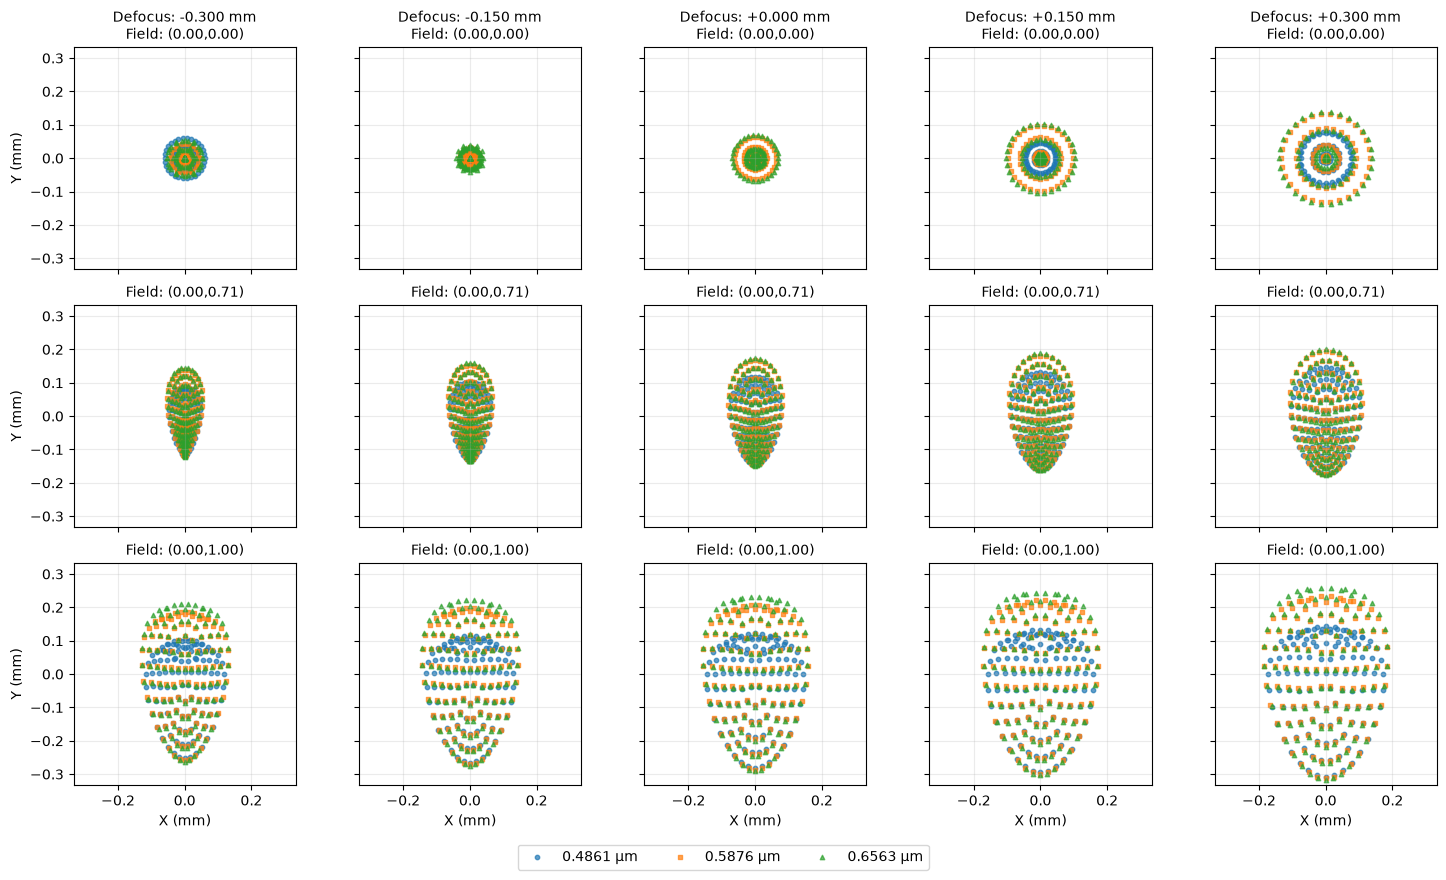

(<Figure size 1500x900 with 15 Axes>,
 [<Axes: title={'center': 'Defocus: -0.300 mm\nField: (0.00,0.00)'}, ylabel='Y (mm)'>,
  <Axes: title={'center': 'Defocus: -0.150 mm\nField: (0.00,0.00)'}>,
  <Axes: title={'center': 'Defocus: +0.000 mm\nField: (0.00,0.00)'}>,
  <Axes: title={'center': 'Defocus: +0.150 mm\nField: (0.00,0.00)'}>,
  <Axes: title={'center': 'Defocus: +0.300 mm\nField: (0.00,0.00)'}>,
  <Axes: title={'center': 'Field: (0.00,0.71)'}, ylabel='Y (mm)'>,
  <Axes: title={'center': 'Field: (0.00,0.71)'}>,
  <Axes: title={'center': 'Field: (0.00,0.71)'}>,
  <Axes: title={'center': 'Field: (0.00,0.71)'}>,
  <Axes: title={'center': 'Field: (0.00,0.71)'}>,
  <Axes: title={'center': 'Field: (0.00,1.00)'}, xlabel='X (mm)', ylabel='Y (mm)'>,
  <Axes: title={'center': 'Field: (0.00,1.00)'}, xlabel='X (mm)'>,
  <Axes: title={'center': 'Field: (0.00,1.00)'}, xlabel='X (mm)'>,
  <Axes: title={'center': 'Field: (0.00,1.00)'}, xlabel='X (mm)'>,
  <Axes: title={'center': 'Field: (0.00,1.0

In [8]:
tf_spot = ThroughFocusSpotDiagram(
    lens,
    num_steps=5,
    delta_focus=0.15,
    fields="all",
    wavelengths="all",
)
tf_spot.view()

### FFT MTF near best focus

A small spacing sweep around the selected focus illustrates how sensitive the image quality is to helicoid position.


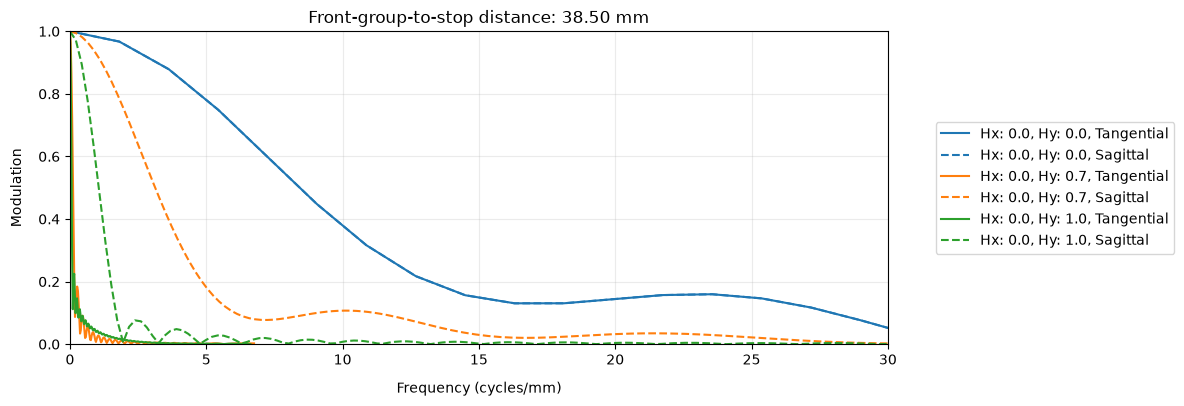

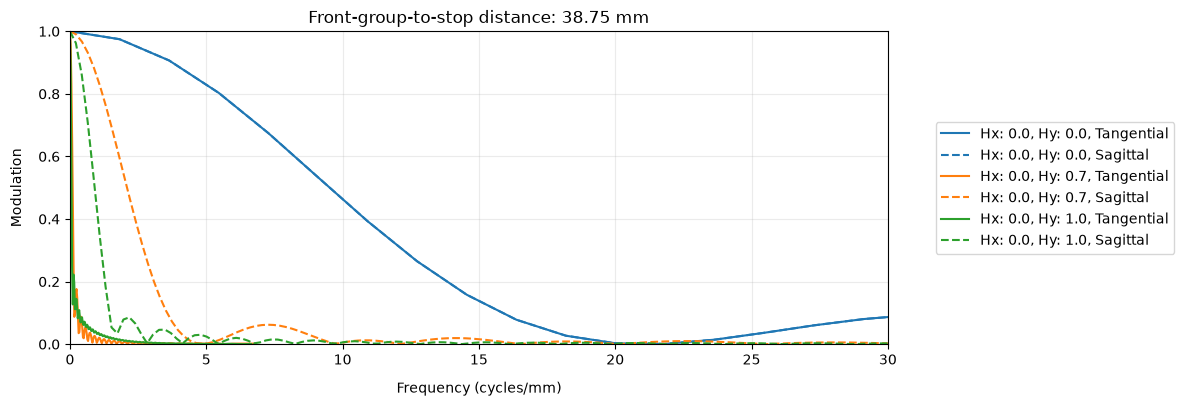

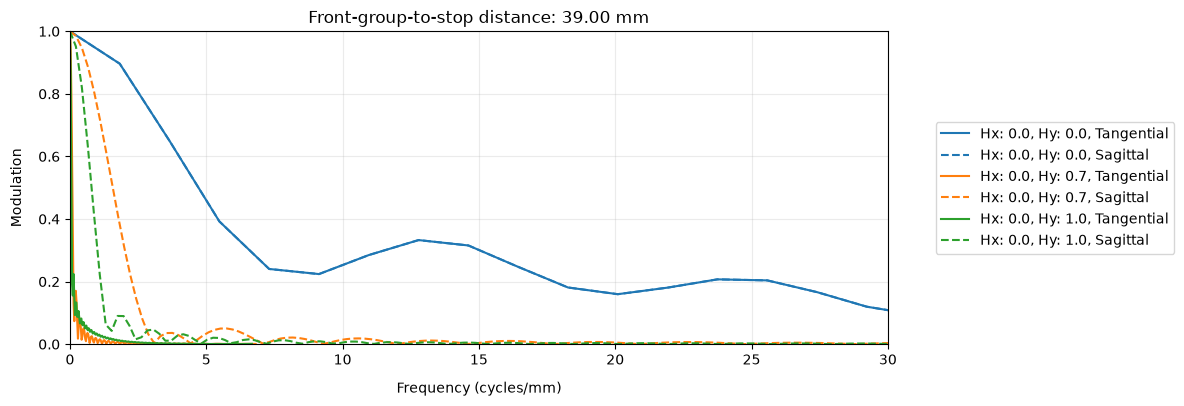

In [9]:
focus_positions = be.linspace(38.5, 39.0, 3)

for spacing in focus_positions:
    spacing = float(spacing)
    lens.updater.set_thickness(spacing, FRONT_GROUP_REAR_SURFACE)

    fft_mtf = FFTMTF(
        lens,
        max_freq=30,
        num_rays=512,
        grid_size=512,
    )
    fft_mtf.view()
    plt.title(f"Front-group-to-stop distance: {spacing:.2f} mm")
    plt.show()

## 6. Assembly tolerancing

For a DIY threaded-tube assembly, group tilt and decenter are likely to dominate over catalog-element manufacturing errors. Here, 100 perturbed systems are generated with independent normal distributions for the front and rear achromats:

- tilt: σ = 1/3 degree about x and y (approximately 1 degree at 3σ)
- decenter: σ = 0.05 mm in x and y (0.15 mm at 3σ)

Because whole-group perturbations are not applied directly in this model, the same rigid-body offsets are assigned to each surface belonging to a given achromat. The resulting on-axis RMS spot radius, astigmatism magnitude, and coma magnitude provide a first-order view of assembly sensitivity. No per-sample refocus compensation is applied in this Monte Carlo run.


In [10]:
num_systems = 100

front_rx = be.random.normal(loc=0, scale=be.deg2rad(1 / 3), size=num_systems)
front_ry = be.random.normal(loc=0, scale=be.deg2rad(1 / 3), size=num_systems)
front_dx = be.random.normal(loc=0, scale=0.05, size=num_systems)
front_dy = be.random.normal(loc=0, scale=0.05, size=num_systems)

rear_rx = be.random.normal(loc=0, scale=be.deg2rad(1 / 3), size=num_systems)
rear_ry = be.random.normal(loc=0, scale=be.deg2rad(1 / 3), size=num_systems)
rear_dx = be.random.normal(loc=0, scale=0.05, size=num_systems)
rear_dy = be.random.normal(loc=0, scale=0.05, size=num_systems)


class LensConfigurable(optic.Optic):
    def __init__(self, rx, ry, dx, dy):
        super().__init__()
        self.rx = rx
        self.ry = ry
        self.dx = dx
        self.dy = dy

        # add surfaces
        self.surfaces.add(index=0, radius=be.inf, thickness=be.inf)
        self.surfaces.add(
            index=1,
            radius=71.12,
            thickness=16,
            material="N-BAF10",
            semi_aperture=22.86,
            dx=dx[0],
            dy=dy[0],
            ry=ry[0],
            rx=rx[0],
        )

        self.surfaces.add(
            index=2,
            radius=-44.17,
            thickness=4,
            material="SF10",
            semi_aperture=22.86,
            dx=dx[0],
            dy=dy[0],
            ry=ry[0],
            rx=rx[0],
        )
        self.surfaces.add(
            index=3,
            radius=-363.1,
            thickness=38.87,
            semi_aperture=22.86,
            dx=dx[0],
            dy=dy[0],
            ry=ry[0],
            rx=rx[0],
        )
        self.surfaces.add(
            index=4, radius=be.inf, thickness=14, semi_aperture=12.5, is_stop=True
        )
        self.surfaces.add(
            index=5,
            radius=706.754,
            thickness=7,
            semi_aperture=22.86,
            material="N-SF2",
            dx=dx[1],
            dy=dy[1],
            ry=ry[1],
            rx=rx[1],
        )
        self.surfaces.add(
            index=6,
            radius=139.918,
            thickness=8.4,
            semi_aperture=22.86,
            material="N-BK7",
            dx=dx[1],
            dy=dy[1],
            ry=ry[1],
            rx=rx[1],
        )
        self.surfaces.add(
            index=7,
            radius=-153.739,
            thickness=4.6,
            semi_aperture=22.86,
            dx=dx[1],
            dy=dy[1],
            ry=ry[1],
            rx=rx[1],
        )
        self.surfaces.add(index=8, radius=be.inf, thickness=1, semi_aperture=14.05)
        self.surfaces.add(index=9, radius=be.inf, thickness=18, semi_aperture=14.02)
        self.surfaces.add(index=10, semi_aperture=14.3)

        # add aperture
        self.set_aperture("float_by_stop_size", 25)

        # add field
        self.fields.set_type(field_type="real_image_height")
        self.fields.add(y=0)
        self.fields.add(y=10)
        self.fields.add(y=14.2)

        # add wavelength
        self.wavelengths.add(value=0.5876, is_primary=True)

In [11]:
rms_spot_radius = []
tot_ast, tot_coma = [], []

for k in range(num_systems):
    # generate one perturbed two-group system
    lens = LensConfigurable(
        [front_rx[k], rear_rx[k]],
        [front_ry[k], rear_ry[k]],
        [front_dx[k], rear_dx[k]],
        [front_dy[k], rear_dy[k]],
    )
    spot = analysis.SpotDiagram(lens)
    value = spot.rms_spot_radius()[0][0]
    rms_spot_radius.append(value)

    zernike = wavefront.ZernikeOPD(
        lens, (0, 0), 0.5876, zernike_type="standard", num_terms=9
    )
    tot_ast.append(be.sqrt(zernike.coeffs[3] ** 2 + zernike.coeffs[5] ** 2))
    tot_coma.append(be.sqrt(zernike.coeffs[7] ** 2 + zernike.coeffs[8] ** 2))

### Monte Carlo results

The distributions below summarize the degradation in on-axis RMS spot radius and low-order asymmetric aberrations across the perturbed assemblies.


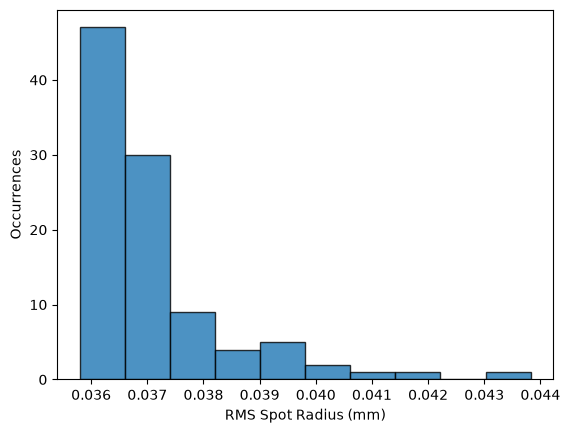

In [12]:
plt.hist(rms_spot_radius, color="C0", edgecolor="k", alpha=0.8)
plt.xlabel("RMS Spot Radius (mm)")
plt.ylabel("Occurrences")
plt.show()

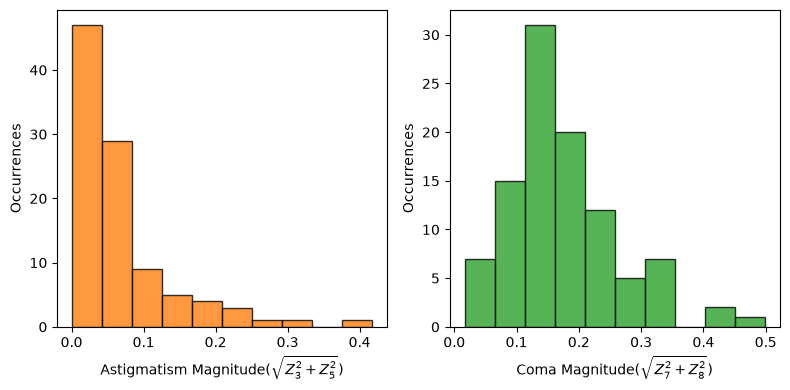

In [13]:
plt.figure(figsize=(8, 4))
plt.subplot(121)
plt.hist(tot_ast, color="C1", edgecolor="k", alpha=0.8)
plt.xlabel("Astigmatism Magnitude($\sqrt{Z_{3}^2+Z_{5}^2}$)")
plt.ylabel("Occurrences")
plt.subplot(122)
plt.hist(tot_coma, color="C2", edgecolor="k", alpha=0.8)
plt.xlabel("Coma Magnitude($\sqrt{Z_{7}^2+Z_{8}^2}$)")
plt.ylabel("Occurrences")
plt.tight_layout()
plt.show()

## 7. Summary

The final model combines two catalog achromats with the actual iris, adapter stack, flange distance, sensor aperture, and helicoid travel. Optimization is intentionally centered on the axial field, preserving stronger off-axis aberrations as part of the portrait-lens character. Through-focus and FFT-MTF analysis establish the usable focus region, while the Monte Carlo study shows how realistic assembly tilt and decenter can affect spot size, coma, and astigmatism.


Further details of the physical realization of the design and sample images can be found here : https://hemkumarsrinivas.github.io/Catalog-to-Camera/
